In [6]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
from geopy.distance import geodesic
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [7]:
# 计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    # 计算路径的实际长度
    path_length = 0
    for i in range(1, len(latitudes)):
        point1 = (latitudes[i-1], longitudes[i-1])
        point2 = (latitudes[i], longitudes[i])
        path_length += geodesic(point1, point2).km
    
    # 计算起点和终点的直线距离
    start_point = (latitudes[0], longitudes[0])
    end_point = (latitudes[-1], longitudes[-1])
    straight_line_distance = geodesic(start_point, end_point).km
    
    # 计算弯曲度
    sinuosity = path_length / straight_line_distance
    return sinuosity

In [8]:
ds = xr.open_dataset('D:/data/GFDL/MOHC/TC-NH_TRACK_HadGEM3-GC31-HH_hist-1950_r1i1p1f1_gn_19500101-20141231.nc')

In [9]:
min_lon = 100
max_lon = 180
min_lat = 0
max_lat = 30

In [10]:
import pandas as pd
import numpy as np
import cftime
import xarray as xr

# ✅ 安全时间转换函数
def safe_to_datetime(times):
    """
    将 cftime 或 numpy.datetime64 类型安全转换为 pandas.Timestamp。
    自动处理 NoLeap、360Day、Gregorian 历法。
    """
    try:
        # ✅ xarray 官方方法，自动处理所有 cftime 类型
        return xr.coding.cftime_offsets.to_datetime_index(times)
    except Exception:
        # 如果转换失败，逐个尝试
        converted = []
        for t in times:
            try:
                if isinstance(t, cftime.DatetimeNoLeap) and t.month == 2 and t.day == 29:
                    t = cftime.DatetimeNoLeap(t.year, 2, 28, t.hour, t.minute, t.second)
                s = t.strftime("%Y-%m-%d %H:%M:%S")
                converted.append(pd.Timestamp(s))
            except Exception:
                converted.append(pd.NaT)
        return pd.to_datetime(converted)

# ----------------------------
# 主循环
# ----------------------------
res_sinuosity = []
res_frequency = []

for yearlis in range(1982, 2015):
    tracks_year = []

    for i in range(ds.sizes['tracks']):
        start_index = ds['FIRST_PT'].isel(tracks=i).item()
        num_pts = ds['NUM_PTS'].isel(tracks=i).item()

        latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
        longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
        times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

        # ✅ 自动识别并转换所有 cftime 类型
        times = safe_to_datetime(times)

        # 若时间中存在 NaT（转换失败），则跳过
        if pd.isna(times).any():
            continue

        # 检查是否经过西北太平洋
        is_nw_pacific = any(
            (min_lon <= lon <= max_lon) and (min_lat <= lat <= max_lat)
            for lat, lon in zip(latitudes, longitudes)
        )

        if is_nw_pacific:
            first_time_dt = times[0]
            last_time_dt = times[-1]
            if pd.isna(first_time_dt) or pd.isna(last_time_dt):
                continue

            # 计算持续时间（小时）
            duration = (last_time_dt - first_time_dt).total_seconds() / 3600

            # 获取风速并计算最大风速（节）
            wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values
            max_wind_speed = np.max(wind_speeds) * 1.9438

            # ✅ 筛选条件
            if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
                track_id = ds['TRACK_ID'].isel(tracks=i).item()
                track_data = ds.isel(record=slice(start_index, start_index + num_pts))

                tracks_year.append({
                    'track_id': track_id,
                    'start_time': first_time_dt,
                    'duration': duration,
                    'max_wind_speed': max_wind_speed,
                    'start_lat': latitudes[0],
                    'start_lon': longitudes[0],
                    'data': track_data
                })

    # 每年符合条件的台风数
    res_frequency.append(len(tracks_year))

    # 计算弯曲度
    sinuosity_values = []
    for track in tracks_year:
        latitudes = track['data']['lat'].values
        longitudes = track['data']['lon'].values

        sinuosity = calculate_sinuosity(latitudes, longitudes)
        if sinuosity < 5:
            sinuosity_values.append(sinuosity)

    average_sinuosity = np.mean(sinuosity_values) if sinuosity_values else 0
    res_sinuosity.append(average_sinuosity)

# ✅ 修复输出年份范围
for y, freq, sinu in zip(range(1982, 2015), res_frequency, res_sinuosity):
    print(f"{y}年7-10月：符合条件的台风数={freq}，平均弯曲度={sinu:.3f}")


1982年7-10月：符合条件的台风数=41，平均弯曲度=1.940
1983年7-10月：符合条件的台风数=31，平均弯曲度=2.130
1984年7-10月：符合条件的台风数=35，平均弯曲度=1.987
1985年7-10月：符合条件的台风数=38，平均弯曲度=1.836
1986年7-10月：符合条件的台风数=39，平均弯曲度=1.811
1987年7-10月：符合条件的台风数=31，平均弯曲度=2.048
1988年7-10月：符合条件的台风数=33，平均弯曲度=1.674
1989年7-10月：符合条件的台风数=44，平均弯曲度=2.195
1990年7-10月：符合条件的台风数=39，平均弯曲度=1.630
1991年7-10月：符合条件的台风数=41，平均弯曲度=1.938
1992年7-10月：符合条件的台风数=30，平均弯曲度=1.939
1993年7-10月：符合条件的台风数=36，平均弯曲度=1.722
1994年7-10月：符合条件的台风数=32，平均弯曲度=1.734
1995年7-10月：符合条件的台风数=39，平均弯曲度=1.847
1996年7-10月：符合条件的台风数=38，平均弯曲度=1.840
1997年7-10月：符合条件的台风数=34，平均弯曲度=2.078
1998年7-10月：符合条件的台风数=34，平均弯曲度=1.966
1999年7-10月：符合条件的台风数=46，平均弯曲度=1.978
2000年7-10月：符合条件的台风数=41，平均弯曲度=1.761
2001年7-10月：符合条件的台风数=44，平均弯曲度=2.034
2002年7-10月：符合条件的台风数=35，平均弯曲度=1.791
2003年7-10月：符合条件的台风数=32，平均弯曲度=1.827
2004年7-10月：符合条件的台风数=34，平均弯曲度=2.087
2005年7-10月：符合条件的台风数=33，平均弯曲度=1.960
2006年7-10月：符合条件的台风数=39，平均弯曲度=1.821
2007年7-10月：符合条件的台风数=39，平均弯曲度=1.995
2008年7-10月：符合条件的台风数=36，平均弯曲度=1.998
2009年7-10月：符合条件的台风数=35，平均弯曲度=2.017
2010年7-10月：符合条件的台风数=

In [11]:
res_sinuosity

[np.float64(1.9402039127067634),
 np.float64(2.129663231433413),
 np.float64(1.9871190419558606),
 np.float64(1.8356520170424366),
 np.float64(1.8105715007248062),
 np.float64(2.0484741926781926),
 np.float64(1.6735427797161984),
 np.float64(2.1949416851872345),
 np.float64(1.6297237297710991),
 np.float64(1.938407324984532),
 np.float64(1.9390925205371299),
 np.float64(1.7224358783326505),
 np.float64(1.7343317454438607),
 np.float64(1.8472128266679861),
 np.float64(1.839789136455412),
 np.float64(2.077567955049038),
 np.float64(1.9657656376308992),
 np.float64(1.9781502817819852),
 np.float64(1.761011916508055),
 np.float64(2.0337096445839875),
 np.float64(1.7905162640307501),
 np.float64(1.8266344560617804),
 np.float64(2.0870516647173347),
 np.float64(1.959608951829504),
 np.float64(1.8209759259106786),
 np.float64(1.994809809543882),
 np.float64(1.9984123542159031),
 np.float64(2.0165803528711246),
 np.float64(1.998974980858363),
 np.float64(1.8619203949380456),
 np.float64(1.7874

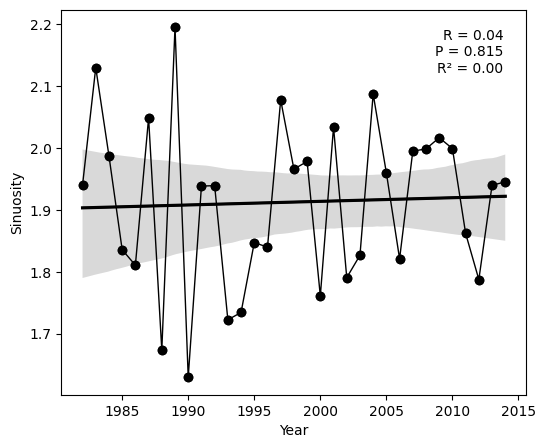

R: 0.04229984622483303
P: 0.8151952845256454
R2: 0.001789276990644521


In [12]:
years = np.arange(1982, 2015)
x=years
y=res_sinuosity
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)